#IMPORT AND INSTALL LIBRARIES

In [ ]:
pi

Found existing installation: joblib 1.5.0
Uninstalling joblib-1.5.0:
  Successfully uninstalled joblib-1.5.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.7/307.7 kB 217.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 23.6 MB/s eta 0:00:00


In [ ]:
!pip install tensorflow

In [ ]:
!pip install mediapipe==0.10.5

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 6.9 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.4
    Uninstalling protobuf-5.29.4:
      Successfully uninstalled protobuf-5.29.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-metadata 1.17.1 requires protobuf<6.0.0,>=4.25.2; python_version >= "3.11", but you have protobuf 3.20.3 which is incompatible.
ydf 0.11.0 requires protobuf<6.0.0,>=5.29.1, but you have protobuf 3.20.3 which is incompatible.
grpcio-status 1.71.0 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 3.20.3 which is incompatible.


In [ ]:
import pandas as pd
import mediapipe as mp
import numpy as np
import os
import cv2
import math
import shutil
import random
import zipfile
import joblib
import time
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from mtcnn import MTCNN
from sklearn.metrics import classification_report, accuracy_score,confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelEncoder,label_binarize
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

#CONVERT VIDEO INTO IMAGE FRAMES USING OPENCV

In [ ]:
video_folder = 'male'               # Folder with videos
output_root = 'extracted_frames'   # Output folder
os.makedirs(output_root, exist_ok=True)

video_extensions = ('.mp4', '.avi', '.mov', '.mkv')
skip_n = 5  # ⬅️ Keep every 5th frame

for video_file in os.listdir(video_folder):
    if video_file.lower().endswith(video_extensions):
        video_path = os.path.join(video_folder, video_file)
        video_name = os.path.splitext(video_file)[0]
        output_dir = os.path.join(output_root, video_name)
        os.makedirs(output_dir, exist_ok=True)

        cap = cv2.VideoCapture(video_path)
        frame_count = 0
        saved_count = 0

        print(f"Processing: {video_file}")
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break

            if frame_count % skip_n == 0:
                frame_filename = os.path.join(output_dir, f'frame_{saved_count:05d}.jpg')
                cv2.imwrite(frame_filename, frame)
                saved_count += 1

            frame_count += 1

        cap.release()
        print(f"Saved {saved_count} frames from {video_file} (every {skip_n}th frame).")

cv2.destroyAllWindows()

Processing: 12-MaleGlasses.avi
Saved 392 frames from 12-MaleGlasses.avi (every 5th frame).
Processing: 5-MaleGlasses.avi
Saved 479 frames from 5-MaleGlasses.avi (every 5th frame).
Processing: 6-MaleGlasses.avi
Saved 327 frames from 6-MaleGlasses.avi (every 5th frame).
Processing: 10-MaleGlasses.avi
Saved 484 frames from 10-MaleGlasses.avi (every 5th frame).
Processing: 4-MaleNoGlasses.avi
Saved 400 frames from 4-MaleNoGlasses.avi (every 5th frame).
Processing: 3-MaleGlasses.avi
Saved 418 frames from 3-MaleGlasses.avi (every 5th frame).
Processing: 2-MaleGlasses.avi
Saved 473 frames from 2-MaleGlasses.avi (every 5th frame).
Processing: 11-MaleGlasses.avi
Saved 352 frames from 11-MaleGlasses.avi (every 5th frame).
Processing: 15-MaleGlasses.avi
Saved 528 frames from 15-MaleGlasses.avi (every 5th frame).
Processing: 8-MaleNoGlasses.avi
Saved 436 frames from 8-MaleNoGlasses.avi (every 5th frame).
Processing: 9-MaleNoGlasses.avi
Saved 404 frames from 9-MaleNoGlasses.avi (every 5th frame).
P

#CONVERT LABELED FRAMES INTO AUTO CROPPED 224x224

In [ ]:
input_root = 'extracted_frames'  # This should contain subfolders for each video
output_root = 'processed_faces_224_rgb'

# Initialize MTCNN detector
detector = MTCNN()

# Create the root output folder
os.makedirs(output_root, exist_ok=True)

# Walk through all subfolders
for subdir, _, files in os.walk(input_root):
    for filename in sorted(files):
        if filename.endswith('.jpg'):
            input_path = os.path.join(subdir, filename)
            image = cv2.imread(input_path)

            if image is None:
                print(f"[!] Failed to read {input_path}")
                continue

            # Convert to RGB for MTCNN
            rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            results = detector.detect_faces(rgb_image)

            if results:
                x, y, w, h = results[0]['box']
                x, y = max(0, x), max(0, y)
                cropped = image[y:y+h, x:x+w]

                # Resize to 224x224
                resized = cv2.resize(cropped, (224, 224))

                # Convert to grayscale
                gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

                # Build output path (preserve folder structure)
                relative_subdir = os.path.relpath(subdir, input_root)
                output_subdir = os.path.join(output_root, relative_subdir)
                os.makedirs(output_subdir, exist_ok=True)

                output_path = os.path.join(output_subdir, filename)
                cv2.imwrite(output_path, gray)
                print(f"[✔] Processed: {output_path}")
            else:
                print(f"[!] No face detected in: {input_path}")

Streaming output truncated to the last 5000 lines.
[✔] Processed: processed_faces_224_rgb/5-MaleGlasses/frame_00110.jpg
[✔] Processed: processed_faces_224_rgb/5-MaleGlasses/frame_00111.jpg
[✔] Processed: processed_faces_224_rgb/5-MaleGlasses/frame_00112.jpg
[✔] Processed: processed_faces_224_rgb/5-MaleGlasses/frame_00113.jpg
[✔] Processed: processed_faces_224_rgb/5-MaleGlasses/frame_00114.jpg
[✔] Processed: processed_faces_224_rgb/5-MaleGlasses/frame_00115.jpg
[✔] Processed: processed_faces_224_rgb/5-MaleGlasses/frame_00116.jpg
[✔] Processed: processed_faces_224_rgb/5-MaleGlasses/frame_00117.jpg
[✔] Processed: processed_faces_224_rgb/5-MaleGlasses/frame_00118.jpg
[✔] Processed: processed_faces_224_rgb/5-MaleGlasses/frame_00119.jpg
[✔] Processed: processed_faces_224_rgb/5-MaleGlasses/frame_00120.jpg
[✔] Processed: processed_faces_224_rgb/5-MaleGlasses/frame_00121.jpg
[✔] Processed: processed_faces_224_rgb/5-MaleGlasses/frame_00122.jpg
[✔] Processed: processed_faces_224_rgb/5-MaleGlasses

#AUTOLABEL FRAMES

In [ ]:
# Path to the zip file
zip_path = 'all_labeled_data.zip'

# Destination directory
extract_to = '/content'

# Create the output folder if it doesn't exist
os.makedirs(extract_to, exist_ok=True)

# Extract the zip file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print(f"[✔] Extracted '{zip_path}' to '{extract_to}'")

[✔] Extracted 'all_labeled_data.zip' to '/content'


In [ ]:
# Thresholds
EAR_THRESHOLD = 0.15
MAR_THRESHOLD = 0.4
MOUTH_CLOSED_THRESHOLD = 0.2

# Paths
faces_root = 'processed_faces_224_rgb'
output_root = 'labeled_faces'
vis_output_root = 'labeled_faces_visualized'

# Create output folders
for cls in ['blinking', 'yawning', 'normal']:
    os.makedirs(os.path.join(output_root, cls), exist_ok=True)
    os.makedirs(os.path.join(vis_output_root, cls), exist_ok=True)

# MediaPipe setup
mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh(static_image_mode=True)

# Landmark indices
LEFT_EYE = [33, 160, 158, 133, 153, 144]
RIGHT_EYE = [362, 385, 387, 263, 373, 380]
MOUTH = [13, 14, 78, 308]

def euclidean(p1, p2):
    return np.linalg.norm(np.array(p1) - np.array(p2))

def calculate_ear(landmarks, indices):
    p = [landmarks[i] for i in indices]
    return (euclidean(p[1], p[5]) + euclidean(p[2], p[4])) / (2.0 * euclidean(p[0], p[3]))

def calculate_mar(landmarks):
    top, bottom = landmarks[13], landmarks[14]
    left, right = landmarks[78], landmarks[308]
    return euclidean(top, bottom) / euclidean(left, right)

def get_landmarks(image):
    rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    results = face_mesh.process(rgb)
    if results.multi_face_landmarks:
        h, w = image.shape[:2]
        return [(int(l.x * w), int(l.y * h)) for l in results.multi_face_landmarks[0].landmark]
    return None

# Process all images
for subdir, _, files in os.walk(faces_root):
    for filename in sorted(files):
        if not filename.lower().endswith('.jpg'):
            continue

        face_path = os.path.join(subdir, filename)
        image = cv2.imread(face_path)
        if image is None:
            continue

        landmarks = get_landmarks(image)
        if landmarks is None:
            continue

        ear = (calculate_ear(landmarks, LEFT_EYE) + calculate_ear(landmarks, RIGHT_EYE)) / 2.0
        mar = calculate_mar(landmarks)

        # Classify
        if ear < EAR_THRESHOLD and mar < MOUTH_CLOSED_THRESHOLD:
            label = 'blinking'
        elif mar > MAR_THRESHOLD:
            label = 'yawning'
        else:
            label = 'normal'

        # Construct new filename: foldername_framename_label.jpg
        folder_name = os.path.basename(subdir)
        base_name = os.path.splitext(filename)[0]
        new_filename = f"{folder_name}_{base_name}_{label}.jpg"

        # Save to labeled dataset
        dst_path = os.path.join(output_root, label, new_filename)
        shutil.copy(face_path, dst_path)

        # Annotate and save visualization
        annotated = image.copy()
        for idx in LEFT_EYE + RIGHT_EYE + MOUTH:
            if idx < len(landmarks):
                cv2.circle(annotated, landmarks[idx], 2, (0, 255, 0), -1)
        vis_path = os.path.join(vis_output_root, label, new_filename)
        cv2.imwrite(vis_path, annotated)

        print(f"[✔] {new_filename} → {label} | EAR={ear:.3f}, MAR={mar:.3f}")


Streaming output truncated to the last 5000 lines.
[✔] 9-MaleNoGlasses_frame_00364_normal.jpg → normal | EAR=0.163, MAR=0.174
[✔] 9-MaleNoGlasses_frame_00365_normal.jpg → normal | EAR=0.159, MAR=0.190
[✔] 9-MaleNoGlasses_frame_00366_normal.jpg → normal | EAR=0.155, MAR=0.189
[✔] 9-MaleNoGlasses_frame_00367_normal.jpg → normal | EAR=0.168, MAR=0.192
[✔] 9-MaleNoGlasses_frame_00368_normal.jpg → normal | EAR=0.151, MAR=0.197
[✔] 9-MaleNoGlasses_frame_00369_normal.jpg → normal | EAR=0.167, MAR=0.162
[✔] 9-MaleNoGlasses_frame_00370_normal.jpg → normal | EAR=0.152, MAR=0.163
[✔] 9-MaleNoGlasses_frame_00371_normal.jpg → normal | EAR=0.170, MAR=0.053
[✔] 9-MaleNoGlasses_frame_00372_normal.jpg → normal | EAR=0.166, MAR=0.167
[✔] 9-MaleNoGlasses_frame_00373_normal.jpg → normal | EAR=0.172, MAR=0.134
[✔] 9-MaleNoGlasses_frame_00374_blinking.jpg → blinking | EAR=0.145, MAR=0.015
[✔] 9-MaleNoGlasses_frame_00375_blinking.jpg → blinking | EAR=0.130, MAR=0.024
[✔] 9-MaleNoGlasses_frame_00376_blinking.

In [ ]:
output_root = 'labeled_faces'
classes = ['blinking', 'yawning', 'normal']

for cls in classes:
    cls_path = os.path.join(output_root, cls)
    count = len([f for f in os.listdir(cls_path) if f.lower().endswith('.jpg')])
    print(f"{cls}: {count} images")

blinking: 490 images
yawning: 370 images
normal: 6532 images


#UNDERSAMPLING

In [ ]:
input_root = 'labeled_faces'
output_root = 'undersampled_faces'

# Class names (adjust if needed)
classes = ['blinking', 'yawning', 'normal']

# Create output folders
for cls in classes:
    os.makedirs(os.path.join(output_root, cls), exist_ok=True)

# Count and list files in each class
class_file_lists = {}
for cls in classes:
    class_path = os.path.join(input_root, cls)
    all_files = [f for f in os.listdir(class_path) if f.endswith('.jpg')]
    class_file_lists[cls] = all_files

# Find the smallest class size
min_count = min(len(files) for files in class_file_lists.values())
print(f"[ℹ] Undersampling to {min_count} images per class.")

# Sample and copy files
for cls, files in class_file_lists.items():
    sampled = random.sample(files, min_count)
    for file in sampled:
        src = os.path.join(input_root, cls, file)
        dst = os.path.join(output_root, cls, file)
        shutil.copy(src, dst)
    print(f"[✔] Copied {min_count} images to '{cls}'.")

print("[✅] Undersampling complete. Output saved in 'undersampled_faces/'")

[ℹ] Undersampling to 302 images per class.
[✔] Copied 302 images to 'blinking'.
[✔] Copied 302 images to 'yawning'.
[✔] Copied 302 images to 'normal'.
[✅] Undersampling complete. Output saved in 'undersampled_faces/'


#DATA AUGMENTATION

In [ ]:
input_root = 'labeled_faces'  # Root directory with your labeled dataset
undersampled_root = 'undersampled_faces'  # After undersampling (300 images per class)
augmented_root = 'augmented_faces'  # Augmented dataset folder
classes = ['blinking', 'yawning', 'normal']  # Class names
augmentation_multiplier = 2  # 1x (600), 2x (900), 3x (1200), etc.
target_augmented_count = 300 * (1 + augmentation_multiplier)  # Total after augmentation

# Create necessary folders for augmented images
for cls in classes:
    os.makedirs(os.path.join(augmented_root, cls), exist_ok=True)

# Image augmentation settings
datagen = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Loop through each class and augment images
for cls in classes:
    src_dir = os.path.join(undersampled_root, cls)
    dst_dir = os.path.join(augmented_root, cls)

    files = os.listdir(src_dir)

    # Step 1: Copy original 300 images to augmented folder
    for file in files:
        shutil.copy(os.path.join(src_dir, file), os.path.join(dst_dir, file))

    # Step 2: Augment images until we reach the target augmented count
    gen_count = 0
    while gen_count < 300 * augmentation_multiplier:
        img_file = random.choice(files)  # Choose a random file to augment
        img_path = os.path.join(src_dir, img_file)
        img = load_img(img_path, target_size=(224, 224))  # Resize image to 224x224
        x = img_to_array(img)
        x = x.reshape((1,) + x.shape)

        # Generate augmented images
        for batch in datagen.flow(x, batch_size=1):
            aug_img = array_to_img(batch[0])
            aug_img.save(os.path.join(dst_dir, f"aug_{gen_count:04d}_{img_file}"))  # Save augmented image
            gen_count += 1
            if gen_count >= 300 * augmentation_multiplier:
                break

    print(f"[✔] {cls} → Augmented to {target_augmented_count} images.")

print("[✅] Augmentation complete. Output saved in 'augmented_faces/'")

[✔] blinking → Augmented to 900 images.
[✔] yawning → Augmented to 900 images.
[✔] normal → Augmented to 900 images.
[✅] Augmentation complete. Output saved in 'augmented_faces/'


In [ ]:
EAR_THRESHOLD = 0.15
MAR_THRESHOLD = 0.4
MOUTH_CLOSED_THRESHOLD = 0.2

# Paths
faces_root = 'augmented_faces'
output_root = 'labeled_faces'
vis_output_root = 'labeled_faces_visualized'
csv_output_path = 'face_metrics.csv'

# Create output folders
for cls in ['blinking', 'yawning', 'normal']:
    os.makedirs(os.path.join(output_root, cls), exist_ok=True)
    os.makedirs(os.path.join(vis_output_root, cls), exist_ok=True)

# MediaPipe setup
mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh(static_image_mode=True)

# Landmark indices
LEFT_EYE = [33, 160, 158, 133, 153, 144]
RIGHT_EYE = [362, 385, 387, 263, 373, 380]
MOUTH = [13, 14, 78, 308]

def euclidean(p1, p2):
    return np.linalg.norm(np.array(p1) - np.array(p2))

def calculate_ear(landmarks, indices):
    p = [landmarks[i] for i in indices]
    return (euclidean(p[1], p[5]) + euclidean(p[2], p[4])) / (2.0 * euclidean(p[0], p[3]))

def calculate_mar(landmarks):
    top, bottom = landmarks[13], landmarks[14]
    left, right = landmarks[78], landmarks[308]
    return euclidean(top, bottom) / euclidean(left, right)

def get_landmarks(image):
    rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    results = face_mesh.process(rgb)
    if results.multi_face_landmarks:
        h, w = image.shape[:2]
        return [(int(l.x * w), int(l.y * h)) for l in results.multi_face_landmarks[0].landmark]
    return None

# Initialize CSV data list
csv_data = []

# Process all images
for subdir, _, files in os.walk(faces_root):
    for filename in sorted(files):
        if not filename.lower().endswith('.jpg'):
            continue

        face_path = os.path.join(subdir, filename)
        image = cv2.imread(face_path)
        if image is None:
            continue

        landmarks = get_landmarks(image)
        if landmarks is None:
            continue

        ear = (calculate_ear(landmarks, LEFT_EYE) + calculate_ear(landmarks, RIGHT_EYE)) / 2.0
        mar = calculate_mar(landmarks)

        # Classify
        if ear < EAR_THRESHOLD and mar < MOUTH_CLOSED_THRESHOLD:
            label = 'blinking'
        elif mar > MAR_THRESHOLD:
            label = 'yawning'
        else:
            label = 'normal'

        # Construct new filename: foldername_framename_label.jpg
        folder_name = os.path.basename(subdir)
        base_name = os.path.splitext(filename)[0]
        new_filename = f"{folder_name}_{base_name}_{label}.jpg"

        # Save to labeled dataset
        dst_path = os.path.join(output_root, label, new_filename)
        shutil.copy(face_path, dst_path)

        # Annotate and save visualization
        annotated = image.copy()
        for idx in LEFT_EYE + RIGHT_EYE + MOUTH:
            if idx < len(landmarks):
                cv2.circle(annotated, landmarks[idx], 2, (0, 255, 0), -1)
        vis_path = os.path.join(vis_output_root, label, new_filename)
        cv2.imwrite(vis_path, annotated)

        print(f"[✔] {new_filename} → {label} | EAR={ear:.3f}, MAR={mar:.3f}")

        # Append to CSV data
        csv_data.append({
            'filename': new_filename,
            'ear': round(ear, 4),
            'mar': round(mar, 4),
            'label': label
        })

# Save CSV


[✔] normal_1-MaleGlasses_frame_00018_normal_normal.jpg → normal | EAR=0.189, MAR=0.090
[✔] normal_1-MaleGlasses_frame_00056_normal_normal.jpg → normal | EAR=0.188, MAR=0.027
[✔] normal_1-MaleGlasses_frame_00083_normal_normal.jpg → normal | EAR=0.200, MAR=0.011
[✔] normal_1-MaleGlasses_frame_00090_normal_normal.jpg → normal | EAR=0.212, MAR=0.098
[✔] normal_1-MaleGlasses_frame_00103_normal_normal.jpg → normal | EAR=0.226, MAR=0.136
[✔] normal_1-MaleGlasses_frame_00104_normal_normal.jpg → normal | EAR=0.196, MAR=0.058
[✔] normal_1-MaleGlasses_frame_00108_normal_normal.jpg → normal | EAR=0.211, MAR=0.047
[✔] normal_1-MaleGlasses_frame_00116_normal_normal.jpg → normal | EAR=0.212, MAR=0.034
[✔] normal_1-MaleGlasses_frame_00130_normal_normal.jpg → normal | EAR=0.210, MAR=0.105
[✔] normal_1-MaleGlasses_frame_00139_normal_normal.jpg → normal | EAR=0.183, MAR=0.095
[✔] normal_1-MaleGlasses_frame_00194_normal_normal.jpg → normal | EAR=0.182, MAR=0.016
[✔] normal_1-MaleGlasses_frame_00242_normal

NameError: name 'pd' is not defined

In [ ]:
df = pd.DataFrame(csv_data)
df.to_csv(csv_output_path, index=False)
print(f"\nCSV file saved to {csv_output_path}")


CSV file saved to face_metrics.csv


In [ ]:
csv_path = 'face_metrics.csv'

# Load CSV
df = pd.read_csv(csv_path)

# Count occurrences of each class in the 'label' column
class_counts = df['label'].value_counts()

# Print counts
for cls in ['blinking', 'yawning', 'normal']:
    count = class_counts.get(cls, 0)
    print(f"{cls}: {count} images")

blinking: 533 images
yawning: 956 images
normal: 1208 images


In [ ]:
csv_path = 'face_metrics_undersampled.csv'

# Load CSV
df = pd.read_csv(csv_path)

# Count occurrences of each class in the 'label' column
class_counts = df['label'].value_counts()

# Print counts
for cls in ['blinking', 'yawning', 'normal']:
    count = class_counts.get(cls, 0)
    print(f"{cls}: {count} images")

blinking: 533 images
yawning: 533 images
normal: 533 images


In [ ]:
csv_path = 'face_metrics.csv'
df = pd.read_csv(csv_path)

# Get class counts
class_counts = df['label'].value_counts()
min_count = class_counts.min()
print(f"[ℹ] Undersampling to {min_count} samples per class.")

# Perform undersampling
undersampled_df = pd.concat([
    df[df['label'] == cls].sample(n=min_count, random_state=42)
    for cls in ['blinking', 'yawning', 'normal']
])

# Shuffle and reset index
undersampled_df = undersampled_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Save to new CSV
undersampled_df.to_csv('face_metrics_undersampled.csv', index=False)
print("[✅] Saved undersampled dataset to 'face_metrics_undersampled.csv'")

[ℹ] Undersampling to 533 samples per class.
[✅] Saved undersampled dataset to 'face_metrics_undersampled.csv'


#FEATURE ENGINEERING + NORMALIZATION

In [ ]:
df = pd.read_csv('face_metrics_undersampled.csv')

# Feature engineering
df['ear_minus_mar'] = df['ear'] - df['mar']
df['ear_div_mar'] = df['ear'] / (df['mar'] + 1e-6)
df['mar_div_ear'] = df['mar'] / (df['ear'] + 1e-6)
df['ear_times_mar'] = df['ear'] * df['mar']

# Normalize all numeric features (including engineered ones)
features_to_scale = ['ear', 'mar', 'ear_minus_mar', 'ear_div_mar', 'mar_div_ear', 'ear_times_mar']
scaler = MinMaxScaler()
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

# Save enhanced and normalized CSV
df.to_csv('face_metrics_enhanced.csv', index=False)
print("[✅] Feature engineering and normalization complete. Saved to 'face_metrics_enhanced.csv'")

[✅] Feature engineering and normalization complete. Saved to 'face_metrics_enhanced.csv'


#LABEL ENCODER

In [ ]:
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])  # e.g., blinking=0, normal=1, yawning=2
class_names = le.classes_

#SHUFFLER

In [ ]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

#MODEL TRAINING

In [ ]:
X = df[['ear', 'mar', 'ear_minus_mar', 'ear_div_mar', 'mar_div_ear', 'ear_times_mar']]
y = df['label_encoded']

# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [ ]:
start = time.time()
svm_model = SVC(kernel='rbf', C=1, gamma='scale')
svm_model.fit(X_train, y_train)
end = time.time()
print(f"[SVM] Training Time: {end - start:.2f} seconds")
print(classification_report(y_test, svm_model.predict(X_test)))
joblib.dump(svm_model, 'model_svm.pkl')

[SVM] Training Time: 0.03 seconds
              precision    recall  f1-score   support

           0       0.87      1.00      0.93       106
           1       0.99      0.85      0.91       107
           2       1.00      0.99      1.00       107

    accuracy                           0.95       320
   macro avg       0.95      0.95      0.95       320
weighted avg       0.95      0.95      0.95       320



['model_svm.pkl']

In [ ]:
print("Train Accuracy:", svm_model.score(X_train, y_train))
print("Test Accuracy:", svm_model.score(X_test, y_test))

Train Accuracy: 0.9538702111024238
Test Accuracy: 0.946875


In [ ]:
start = time.time()
nb_model = GaussianNB(var_smoothing=1e-9)
nb_model.fit(X_train, y_train)
end = time.time()
print(f"[Naive Bayes] Training Time: {end - start:.2f} seconds")
print(classification_report(y_test, nb_model.predict(X_test)))
joblib.dump(nb_model, 'model_nb.pkl')

[Naive Bayes] Training Time: 0.01 seconds
              precision    recall  f1-score   support

           0       0.80      0.89      0.84       106
           1       0.80      0.46      0.58       107
           2       0.75      1.00      0.86       107

    accuracy                           0.78       320
   macro avg       0.79      0.78      0.76       320
weighted avg       0.79      0.78      0.76       320



['model_nb.pkl']

In [ ]:
print("Train Accuracy:", nb_model.score(X_train, y_train))
print("Test Accuracy:", nb_model.score(X_test, y_test))

Train Accuracy: 0.8060985144644254
Test Accuracy: 0.78125


In [ ]:
xgb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'min_child_weight': [1, 3],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.1]
}

xgb_grid = GridSearchCV(
    estimator=XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    param_grid=xgb_params,
    cv=5,
    scoring='accuracy'
)

start = time.time()
xgb_grid.fit(X_train, y_train)
end = time.time()

xgb_best = xgb_grid.best_estimator_
print(f"[XGBoost] Best Parameters: {xgb_grid.best_params_}")
print(f"[XGBoost] Training Time: {end - start:.2f} seconds")
print(classification_report(y_test, xgb_best.predict(X_test)))
joblib.dump(xgb_best, 'model_xgb.pkl')

print("\n✅ XGBoost model trained, optimized, and saved as 'model_xgb.pkl'.")

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [23:59:03] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [23:59:03] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [23:59:03] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [23:59:03] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [23:59:04] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

KeyboardInterrupt: 

In [ ]:
print("Train Accuracy:", xgb_grid.score(X_train, y_train))
print("Test Accuracy:", xgb_grid.score(X_test, y_test))

In [ ]:
start = time.time()
logreg_model = LogisticRegression(max_iter=1000, random_state=42)
logreg_model.fit(X_train, y_train)
end = time.time()

# Evaluate
print(f"[Logistic Regression] Training Time: {end - start:.2f} seconds")
print(classification_report(y_test, logreg_model.predict(X_test)))

# Save model and scaler
joblib.dump(logreg_model, 'model_logreg.pkl')
joblib.dump(scaler, 'scaler_logreg.pkl')

print("\n✅ Logistic Regression model trained and saved.")

[Logistic Regression] Training Time: 0.03 seconds
              precision    recall  f1-score   support

           0       0.85      1.00      0.92       106
           1       0.99      0.82      0.90       107
           2       1.00      0.99      1.00       107

    accuracy                           0.94       320
   macro avg       0.95      0.94      0.94       320
weighted avg       0.95      0.94      0.94       320


✅ Logistic Regression model trained and saved.


In [ ]:
print("Train Accuracy:", logreg_model.score(X_train, y_train))
print("Test Accuracy:", logreg_model.score(X_test, y_test))

Train Accuracy: 0.9374511336982018
Test Accuracy: 0.9375


#EVALUATE


🧠 Evaluating SVM
Accuracy: 0.9469
              precision    recall  f1-score   support

    blinking       0.87      1.00      0.93       106
      normal       0.99      0.85      0.91       107
     yawning       1.00      0.99      1.00       107

    accuracy                           0.95       320
   macro avg       0.95      0.95      0.95       320
weighted avg       0.95      0.95      0.95       320



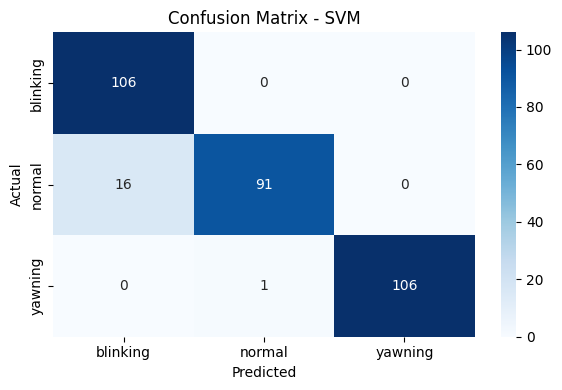


🧠 Evaluating Naive Bayes
Accuracy: 0.7812
              precision    recall  f1-score   support

    blinking       0.80      0.89      0.84       106
      normal       0.80      0.46      0.58       107
     yawning       0.75      1.00      0.86       107

    accuracy                           0.78       320
   macro avg       0.79      0.78      0.76       320
weighted avg       0.79      0.78      0.76       320



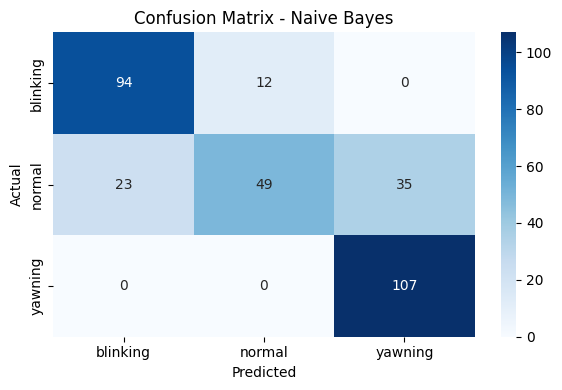

ROC AUC Score: 0.9639

🧠 Evaluating XGB
Accuracy: 1.0000
              precision    recall  f1-score   support

    blinking       1.00      1.00      1.00       106
      normal       1.00      1.00      1.00       107
     yawning       1.00      1.00      1.00       107

    accuracy                           1.00       320
   macro avg       1.00      1.00      1.00       320
weighted avg       1.00      1.00      1.00       320



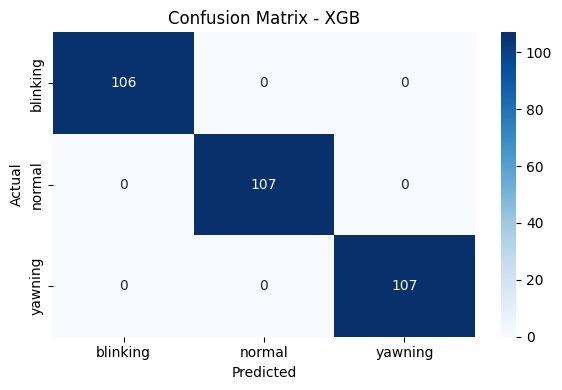

ROC AUC Score: 1.0000

🧠 Evaluating LR
Accuracy: 0.9375
              precision    recall  f1-score   support

    blinking       0.85      1.00      0.92       106
      normal       0.99      0.82      0.90       107
     yawning       1.00      0.99      1.00       107

    accuracy                           0.94       320
   macro avg       0.95      0.94      0.94       320
weighted avg       0.95      0.94      0.94       320



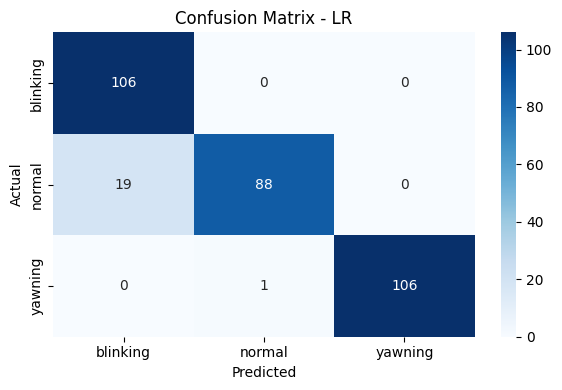

ROC AUC Score: 0.9986


In [ ]:
model_files = {
    'SVM': 'model_svm.pkl',
    'Naive Bayes': 'model_nb.pkl',
    'XGB': 'model_xgb.pkl',
    'LR': 'model_logreg.pkl',


}

# Evaluation loop
for model_name, file in model_files.items():
    print(f"\n🧠 Evaluating {model_name}")
    model = joblib.load(file)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=class_names))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    # ROC-AUC (for models that support probability)
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)
        y_bin = label_binarize(y_test, classes=list(range(len(class_names))))
        auc = roc_auc_score(y_bin, y_score, multi_class='ovr')
        print(f"ROC AUC Score: {auc:.4f}")

In [ ]:
import joblib

# Load the model
model = joblib.load('model_nb.pkl')



Saving blinkwoman3.png to blinkwoman3.png


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/valid

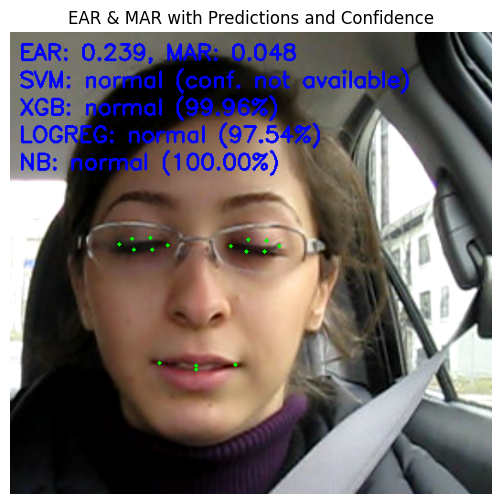

EAR: 0.2388, MAR: 0.0482
Raw Features: [[0.23883225 0.04817879 0.19065347 4.95710489 0.20172562 0.01150665]]
Scaled Features: [[5.19077596e-01 5.94579612e-02 8.48702494e-01 2.07594820e-05
  2.17246175e-02 6.66241752e-02]]

Predictions:
  svm: normal (confidence not available)
  xgb: normal (99.96% confidence)
  logreg: normal (97.54% confidence)
  nb: normal (100.00% confidence)


In [ ]:
import cv2
import numpy as np
import mediapipe as mp
from google.colab import files
import matplotlib.pyplot as plt
import joblib
from sklearn.preprocessing import MinMaxScaler

# === Load models ===
models = {
    'svm':    joblib.load('model_svm.pkl'),
    'xgb':    joblib.load('model_xgb.pkl'),
    'logreg': joblib.load('model_logreg.pkl'),
    'nb':     joblib.load('model_nb.pkl'),
}

# === Load scaler ===
scaler = joblib.load('scaler_logreg.pkl')

# === Upload and load image ===
image_file = files.upload()
image = cv2.imread(list(image_file.keys())[0])

# === MediaPipe FaceMesh setup ===
mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh(static_image_mode=True)

# === Landmark indices ===
LEFT_EYE = [33, 160, 158, 133, 153, 144]
RIGHT_EYE = [362, 385, 387, 263, 373, 380]
MOUTH = [13, 14, 78, 308]

# === Helper functions ===
def euclidean(p1, p2):
    return np.linalg.norm(np.array(p1) - np.array(p2))

def calculate_ear(landmarks, indices):
    p = [landmarks[i] for i in indices]
    return (euclidean(p[1], p[5]) + euclidean(p[2], p[4])) / (2.0 * euclidean(p[0], p[3]))

def calculate_mar(landmarks):
    top, bottom = landmarks[13], landmarks[14]
    left, right = landmarks[78], landmarks[308]
    return euclidean(top, bottom) / euclidean(left, right)

def get_landmarks(image):
    rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    results = face_mesh.process(rgb)
    if results.multi_face_landmarks:
        h, w = image.shape[:2]
        return [(int(l.x * w), int(l.y * h)) for l in results.multi_face_landmarks[0].landmark]
    return None

# === Class label mapping ===
mapping = {0: "blinking", 1: "normal", 2: "yawning"}

# === Process image and predict ===
landmarks = get_landmarks(image)
if landmarks:
    ear = (calculate_ear(landmarks, LEFT_EYE) + calculate_ear(landmarks, RIGHT_EYE)) / 2.0
    mar = calculate_mar(landmarks)

    # Feature engineering
    diff = ear - mar
    ratio1 = ear / (mar + 1e-6)
    ratio2 = mar / (ear + 1e-6)
    product = ear * mar
    features = np.array([[ear, mar, diff, ratio1, ratio2, product]])
    features_scaled = scaler.transform(features)

    # Predict using all models
    predictions = {}
    for name, model in models.items():
        y_pred = model.predict(features_scaled)[0]
        label = mapping.get(int(y_pred), "unknown")
        try:
            probs = model.predict_proba(features_scaled)[0]
            confidence = np.max(probs)  # highest class probability
        except AttributeError:
            confidence = None  # model does not support predict_proba
        predictions[name] = (label, confidence)

    # Annotate image
    annotated = image.copy()
    for idx in LEFT_EYE + RIGHT_EYE + MOUTH:
        if idx < len(landmarks):
            cv2.circle(annotated, landmarks[idx], 2, (0, 255, 0), -1)

    # Compose overlay text
    text_lines = [f"EAR: {ear:.3f}, MAR: {mar:.3f}"]
    for model_name, (label, conf) in predictions.items():
        if conf is not None:
            line = f"{model_name.upper()}: {label} ({conf:.2%})"
        else:
            line = f"{model_name.upper()}: {label} (conf. not available)"
        text_lines.append(line)

    for i, line in enumerate(text_lines):
        cv2.putText(annotated, line, (10, 30 + 30 * i), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)

    # Show annotated image
    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    plt.title("EAR & MAR with Predictions and Confidence")
    plt.axis('off')
    plt.show()

    # Print debug info
    print(f"EAR: {ear:.4f}, MAR: {mar:.4f}")
    print(f"Raw Features: {features}")
    print(f"Scaled Features: {features_scaled}")
    print("\nPredictions:")
    for name, (label, conf) in predictions.items():
        if conf is not None:
            print(f"  {name}: {label} ({conf:.2%} confidence)")
        else:
            print(f"  {name}: {label} (confidence not available)")
else:
    print("❌ No face landmarks detected.")
